In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

## 1. Load Processed Data

In [2]:
df = pd.read_csv('../data/processed/procurement_processed.csv')
print(f"Loaded: {len(df)} contracts")
df.head()

Loaded: 59 contracts


,Bid Reference No.,Procuring Entity,Region,Classification,Procurement Mode,Approved Budget of the Contract (ABC),Published Date,Closing Date,Award Date,Contract Amount,Contract Duration,Awardee Organization Name,Awardee Size,Notice Title,price_variance_pct,bidding_duration_days,award_speed_days,winner_frequency
0,3827,PHILIPPINE COMMISSION ON SPORTS SCUBA DIVING,NCR,Goods,Small Value Procurement,151500.0,2025-01-16,2025-01-20,2025-01-20,1.515000e+05,3,EAS - ELLEN'S TRAVEL & TOURS,Micro,Conduct of BOT Regular/Special Meeting,0.000000,4,0,1
1,3843,DEPARTMENT OF PUBLIC WORKS AND HIGHWAYS - MAIN,NCR,Consulting Services,Public Bidding,571629232.5,2025-01-17,2025-02-27,2025-07-15,5.354561e+08,44,WOODFIELDS ENGINEERS COMPANY,Medium,CONSULTING SERVICES FOR THE CONSTRUCTION SUPER...,-6.328069,41,138,1
2,4001,PHILIPPINE RICE RESEARCH INSTITUTE,Region III,Consulting Services,Small Value Procurement,220000.0,2025-02-04,2025-02-10,2025-03-04,2.000000e+05,11,DR RACQUEL YAMBALLA QUILANG,Micro,Procurement of Service for 2025 PhilRice Medic...,-9.090909,6,22,1
3,4002,PHILIPPINE RICE RESEARCH INSTITUTE,Region III,Goods,Small Value Procurement,130500.0,2025-02-04,2025-02-07,2025-02-10,1.122000e+05,3,CHEF-DE-CUISINE FOOD STORE,Micro,Catering Services for the 2024 DA-PhilRice Ann...,-14.022989,3,3,2
4,4004,PHILIPPINE RICE RESEARCH INSTITUTE,Region III,Civil Works - Infra Project,Public Bidding,1510005.0,2025-02-05,2025-02-25,2025-03-20,1.320034e+06,120,G.R. ERCILLA CONSTRUCTION,Micro,One (1) lot Replacement of Floor Tiles at Rice...,-12.580836,20,23,1


## 2. Select Features for Model

In [3]:
# Select numerical features
feature_cols = [
    'Approved Budget of the Contract (ABC)',
    'Contract Amount',
    'price_variance_pct',
    'bidding_duration_days',
    'award_speed_days',
    'winner_frequency',
    'Contract Duration'
]

# Create feature matrix
X = df[feature_cols].copy()
print(f"\nFeature matrix shape: {X.shape}")
print("\nFeature statistics:")
print(X.describe())


Feature matrix shape: (59, 7)

Feature statistics:
       Approved Budget of the Contract (ABC)  Contract Amount  \
count                           5.900000e+01     5.900000e+01   
mean                            1.375127e+07     1.279875e+07   
std                             7.516484e+07     7.034404e+07   
min                             4.825000e+04     4.112500e+04   
25%                             1.250275e+05     1.138650e+05   
50%                             3.244500e+05     2.200000e+05   
75%                             1.192965e+06     8.183250e+05   
max                             5.716292e+08     5.354561e+08   

       price_variance_pct  bidding_duration_days  award_speed_days  \
count           59.000000              59.000000         59.000000   
mean           -13.360061               9.677966         24.271186   
std             17.593100               9.366928         24.257122   
min            -72.659506               3.000000          0.000000   
25%         

## 3. Scale Features

In [4]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled ✅")

Features scaled ✅


## 4. Run Isolation Forest

In [5]:
# Initialize Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1,  # Expect 10% anomalies
    random_state=42,
    n_jobs=-1
)

# Fit and predict
df['anomaly_label'] = iso_forest.fit_predict(X_scaled)
df['anomaly_score'] = iso_forest.score_samples(X_scaled)

# Convert labels: -1 = anomaly, 1 = normal
df['is_anomaly'] = df['anomaly_label'] == -1

print(f"\n✅ Isolation Forest completed")
print(f"\nAnomalies detected: {df['is_anomaly'].sum()} ({df['is_anomaly'].sum()/len(df)*100:.1f}%)")
print(f"Normal contracts: {(~df['is_anomaly']).sum()}")


✅ Isolation Forest completed

Anomalies detected: 6 (10.2%)
Normal contracts: 53


## 5. Analyze Anomalies

In [6]:
# Get anomalies
anomalies = df[df['is_anomaly']].copy()
anomalies = anomalies.sort_values('anomaly_score')

print("Top 10 Most Anomalous Contracts:")
print(anomalies[[
    'Bid Reference No.', 'Notice Title', 'Procuring Entity',
    'Approved Budget of the Contract (ABC)', 'Contract Amount',
    'price_variance_pct', 'anomaly_score'
]].head(10))

Top 10 Most Anomalous Contracts:
    Bid Reference No.                                       Notice Title  \
1                3843  CONSULTING SERVICES FOR THE CONSTRUCTION SUPER...   
55               4848  PB No. 25-010-1 Supply and Delivery of Alcohol...   
18               4179  PROVISION OF SECURITY SERVICES FOR DFPC STORES...   
10               4094  One (1) lot Supply, Delivery, and Installation...   
11               4095  Supply and Delivery of (Lot1) Gel Documentatio...   
4                4004  One (1) lot Replacement of Floor Tiles at Rice...   

                                  Procuring Entity  \
1   DEPARTMENT OF PUBLIC WORKS AND HIGHWAYS - MAIN   
55                         PROCUREMENT SERVICE CSE   
18               DUTY FREE PHILIPPINES CORPORATION   
10              PHILIPPINE RICE RESEARCH INSTITUTE   
11              PHILIPPINE RICE RESEARCH INSTITUTE   
4               PHILIPPINE RICE RESEARCH INSTITUTE   

    Approved Budget of the Contract (ABC)  Contract Amo

## 6. Visualize Results

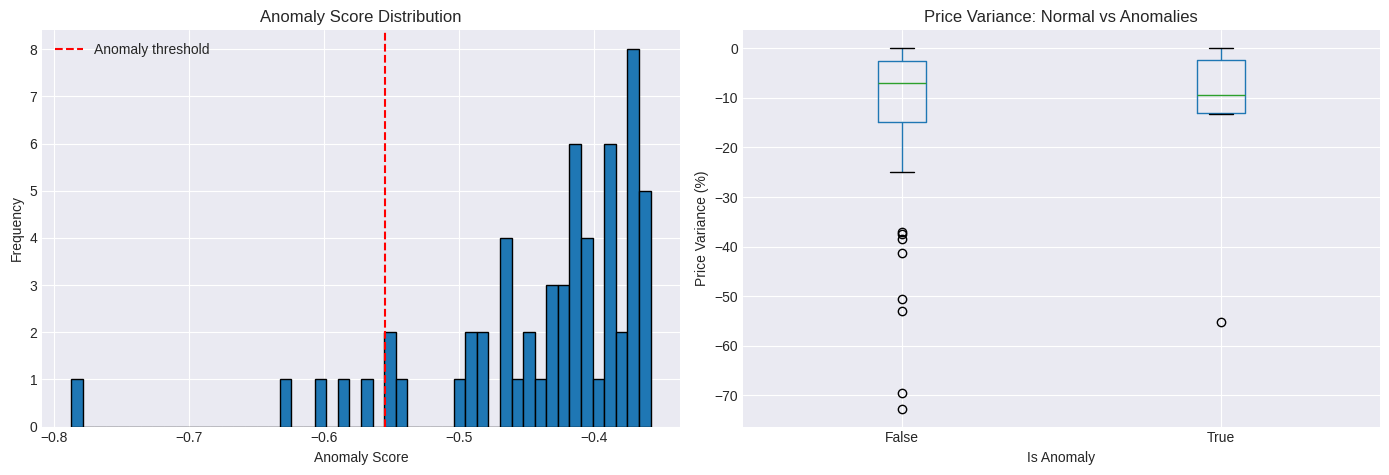

In [7]:
# Anomaly score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(df['anomaly_score'], bins=50, edgecolor='black')
axes[0].axvline(df[df['is_anomaly']]['anomaly_score'].max(), 
                color='red', linestyle='--', label='Anomaly threshold')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Anomaly Score Distribution')
axes[0].legend()

# Price variance comparison
df.boxplot(column='price_variance_pct', by='is_anomaly', ax=axes[1])
axes[1].set_xlabel('Is Anomaly')
axes[1].set_ylabel('Price Variance (%)')
axes[1].set_title('Price Variance: Normal vs Anomalies')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [8]:
# Feature comparison: anomalies vs normal
comparison = pd.DataFrame({
    'Normal': df[~df['is_anomaly']][feature_cols].mean(),
    'Anomalies': df[df['is_anomaly']][feature_cols].mean()
})

print("\nFeature Averages: Normal vs Anomalies")
print(comparison)


Feature Averages: Normal vs Anomalies
                                             Normal     Anomalies
Approved Budget of the Contract (ABC)  1.704186e+06  1.201672e+08
Contract Amount                        1.580853e+06  1.118902e+08
price_variance_pct                    -1.320917e+01 -1.469293e+01
bidding_duration_days                  7.792453e+00  2.633333e+01
award_speed_days                       1.954717e+01  6.600000e+01
winner_frequency                       1.301887e+00  1.333333e+00
Contract Duration                      1.179245e+01  4.766667e+01


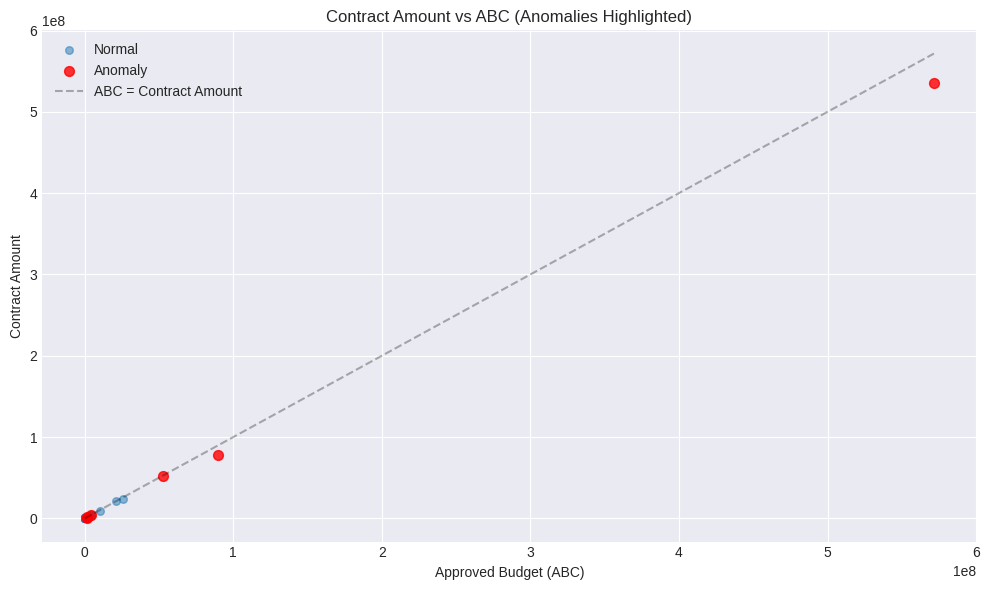

In [9]:
# Scatter plot: ABC vs Contract Amount
plt.figure(figsize=(10, 6))
plt.scatter(df[~df['is_anomaly']]['Approved Budget of the Contract (ABC)'],
           df[~df['is_anomaly']]['Contract Amount'],
           alpha=0.5, label='Normal', s=30)
plt.scatter(df[df['is_anomaly']]['Approved Budget of the Contract (ABC)'],
           df[df['is_anomaly']]['Contract Amount'],
           alpha=0.8, label='Anomaly', s=50, color='red')
plt.plot([0, df['Approved Budget of the Contract (ABC)'].max()],
         [0, df['Approved Budget of the Contract (ABC)'].max()],
         'k--', alpha=0.3, label='ABC = Contract Amount')
plt.xlabel('Approved Budget (ABC)')
plt.ylabel('Contract Amount')
plt.title('Contract Amount vs ABC (Anomalies Highlighted)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Save Results

In [10]:
# Save flagged anomalies
results_path = Path('../results')
results_path.mkdir(exist_ok=True)

# Save all results
df.to_csv(results_path / 'baseline_isolation_forest_results.csv', index=False)

# Save just anomalies
anomalies.to_csv(results_path / 'baseline_anomalies.csv', index=False)

print(f"✅ Results saved to {results_path}")
print(f"   - Full results: baseline_isolation_forest_results.csv")
print(f"   - Anomalies only: baseline_anomalies.csv ({len(anomalies)} records)")

✅ Results saved to ../results
   - Full results: baseline_isolation_forest_results.csv
   - Anomalies only: baseline_anomalies.csv (6 records)


## Summary

**Baseline Isolation Forest completed!**

This provides the benchmark for comparing the enhanced weighted Isolation Forest.

**Next:** Implement feature weighting and weighted Isolation Forest in notebooks 04-05.